In [9]:
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

caminho = '/content/drive/MyDrive/Ciência de Dados/Dados/censo2022.xlsx'
arquivo = pd.read_excel(caminho)

dados = arquivo.iloc[3:].copy()
col_regiao = dados.columns[0]

brasil = dados.iloc[0:1]          # Linha do Total Brasil
regioes = dados.iloc[1:6].copy()  # As Regiões
estados = dados.iloc[6:33].copy() # Os estados

In [10]:
# 1) Sem Instrução (Regiões)
t1 = regioes[[col_regiao, 'Unnamed: 1']].copy()
t1.columns = ['Região', 'Percentual']
t1['Percentual'] = pd.to_numeric(t1['Percentual'])

fig1 = px.bar(
    t1,
    x='Região',
    y='Percentual',
    color='Região',
    title='1. Percentual de Pessoas "Sem instrução e fundamental incompleto" (Total)',
    text_auto='.1f'
)
fig1.show()

In [17]:
# 2)Homens vs Mulheres (Sem Instrução)
t2 = regioes[[col_regiao, 'Unnamed: 5', 'Unnamed: 9']].copy()
t2.columns = ['Região', 'Homens', 'Mulheres']

t2['Homens'] = pd.to_numeric(t2['Homens'])
t2['Mulheres'] = pd.to_numeric(t2['Mulheres'])

t2_long = t2.melt(id_vars='Região', var_name='Sexo', value_name='Percentual (%)')

fig2 = px.bar(
    t2_long,
    x='Região',
    y='Percentual (%)',
    color='Sexo',
    barmode='group',
    title='2. Disparidade Educacional: Homens vs Mulheres "Sem instrução"',
    text_auto='.1f',
    color_discrete_map={'Homens': '#1f77b4', 'Mulheres': '#d62728'}
)
fig2.show()

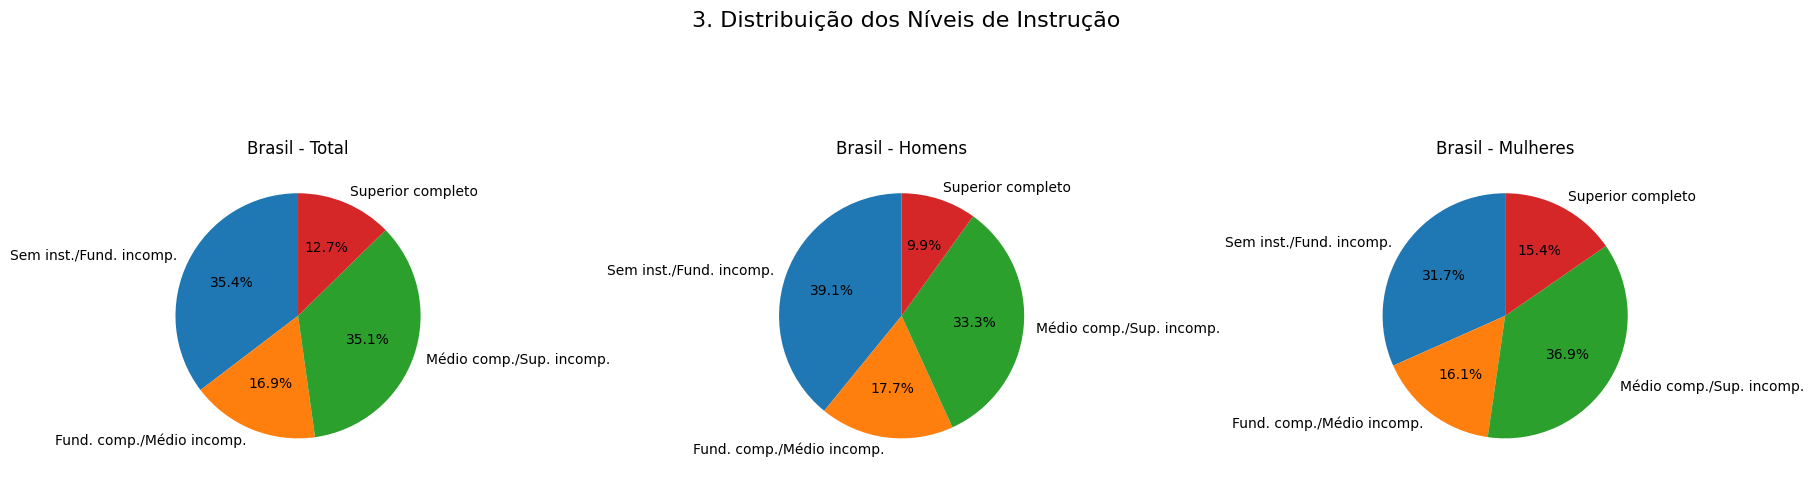

In [18]:
# 3)Níveis de instrução do Brasil
niveis = [
    'Sem inst./Fund. incomp.',
    'Fund. comp./Médio incomp.',
    'Médio comp./Sup. incomp.',
    'Superior completo'
]

total = pd.to_numeric(brasil[['Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']].iloc[0]).values
homens = pd.to_numeric(brasil[['Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8']].iloc[0]).values
mulheres = pd.to_numeric(brasil[['Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12']].iloc[0]).values

fig3, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].pie(total, labels=niveis, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Brasil - Total')

axes[1].pie(homens, labels=niveis, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Brasil - Homens')

axes[2].pie(mulheres, labels=niveis, autopct='%1.1f%%', startangle=90)
axes[2].set_title('Brasil - Mulheres')

plt.suptitle('3. Distribuição dos Níveis de Instrução', fontsize=16)
plt.tight_layout()
plt.show()

In [19]:
# 6) gráfico de dispersão por estado
t6 = estados[[col_regiao, 'Unnamed: 1', 'Unnamed: 4']].copy()
t6.columns = ['UF', 'Sem_Instrucao', 'Superior_Completo']

t6['Sem_Instrucao'] = pd.to_numeric(t6['Sem_Instrucao'], errors='coerce')
t6['Superior_Completo'] = pd.to_numeric(t6['Superior_Completo'], errors='coerce')
t6 = t6.dropna()

fig6 = px.scatter(
    t6,
    x='Sem_Instrucao',
    y='Superior_Completo',
    hover_name='UF',
    title='6. Dispersão: Sem Instrução vs Superior Completo (Por Estado)',
    labels={
        'Sem_Instrucao': 'Sem Instrução e Fund. Incompleto (%)',
        'Superior_Completo': 'Superior Completo (%)'
    },
    trendline='ols'
)
fig6.show()

correlacao = t6['Sem_Instrucao'].corr(t6['Superior_Completo'])
print(f"Coeficiente de Correlação de Pearson: {correlacao:.4f}")

Coeficiente de Correlação de Pearson: -0.8350


In [20]:
import pandas as pd
import plotly.express as px

caminho = '/content/drive/MyDrive/Ciência de Dados/Dados/censo2022.xlsx'

# Lendo a aba específica da planilha
aba = pd.read_excel(caminho, sheet_name='Tabela base do SIDRA 10061', header=None)

regioes_abs = aba.iloc[9:14].copy()

pizza = regioes_abs[[0, 2, 5]].copy()
pizza.columns = ['Região', 'Sem_Instrucao', 'Superior_Completo']

pizza['Sem_Instrucao'] = pd.to_numeric(pizza['Sem_Instrucao'])
pizza['Superior_Completo'] = pd.to_numeric(pizza['Superior_Completo'])

In [21]:
# 4)Participação no Montante Total de Pessoas Sem Instrução
fig4 = px.pie(
    pizza,
    names='Região',
    values='Sem_Instrucao',
    title='4. Proporção Regional do Volume Total de Pessoas "Sem Instrução" no Brasil',
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig4.update_traces(textposition='inside', textinfo='percent+label')
fig4.show()

In [22]:
# 5) Concentração de Mão de Obra Altamente Qualificada
fig5 = px.pie(
    pizza,
    names='Região',
    values='Superior_Completo',
    title='5. Concentração Regional da População com "Superior Completo"',
    hole=0.4, # Deixa em formato de "Donut"
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig5.update_traces(textposition='inside', textinfo='percent+label')
fig5.show()

Desigualdade socioeconômica regional no Brasil. Estados que possuem altas taxas de "Sem instrução e fundamental incompleto" falham em construir a base educacional primária. Como a educação é um funil, a ausência dessa base cria um gargalo, resultando em pouquíssimos indivíduos "Superior completo".